In [1]:
# DOI analysis
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from matplotlib import patches
import random
from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import glob
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if hist[-1*i] >= 0.5 * np.max(hist):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])

    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, _ = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])
        except:
            pass
    return fit_p

# Define valid index pairs in DOI crystals
index_pairs = []
for i in range(64, 128):
    coord = indices[i]
    # find the dictionary key with value (coord[0], 7-coord[1])
    other = next(k for k, v in indices.items() if v == (coord[0], 7-coord[1]))
    index_pairs.append((i, other))

def get_compliment(index):
    # Get the second index of the pair with the given index as the first index
    return next(pair[1] for pair in index_pairs if pair[0] == index)

# Hardcode indices
indicesL = [119, 118, 124, 115, 127, 117, 113, 111]
indicesR = [get_compliment(i) for i in indicesL]
print(indicesL, indicesR)

[119, 118, 124, 115, 127, 117, 113, 111] [69, 72, 74, 67, 64, 65, 80, 85]


In [74]:
# Read in data
referencemodulecolumns = (0, 1, 2, 3, 4, 5, 6, 7) # all
referencemodulecolumns = (3, 4) # high activity columns
#module_ids = [k for k, v in indices.items() if v[1] in referencemodulecolumns]

paths0 = sorted(glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/0um', '*.txt')))
paths5 = sorted(glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/4um', '*.txt')))
paths14 = sorted(glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/14um', '*.txt')))
paths28 = sorted(glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/28um', '*.txt')))
pathslist = [paths0, paths5, paths14, paths28]
doi_data = [] # Will be filled to contain 4 lists of 7 datasets each
for paths in tqdm(pathslist):
    curr_data = []
    # Find two columns with highest counts to be used for digital collimator, use 15mm position
    df = pd.read_csv(paths[3], sep = '\t', header=None)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    dat = np.asarray(df, dtype = np.float32)
    dat = dat[np.isin(dat[:, 5] % 128, indicesL)] # Relevant indices
    dat = dat[np.isin(dat[:, 1] % 128, indicesR)] # Relevant indices
    columncounts = np.zeros((8), dtype=np.int32)
    for col in range(8):
        list_indices = dict(sorted(
            ((k, v) for k, v in indices.items() if v[1] == col),
            key=lambda item: item[1][0]
        ))
        list_indices = list(list_indices.keys())
        column = dat[np.isin(dat[:, 3] % 128, list_indices)]   
        columncounts[col] = len(column)
    columns = (0, 1)
    for colpair in range(7):
        if columncounts[colpair] + columncounts[colpair+1] > columncounts[columns[0]] + columncounts[columns[1]]:
            columns = (colpair, colpair+1)
    module_ids = [k for k, v in indices.items() if v[1] in columns]
    print(columncounts, columns)
    for path in paths:
        df = pd.read_csv(path, sep = '\t', header=None)
        df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
        dat = np.asarray(df, dtype = np.float32)
        dat = dat[np.isin(dat[:, 3] % 128, module_ids)]
        dat = dat[np.isin(dat[:, 5] % 128, indicesL)] # Relevant indices
        dat = dat[np.isin(dat[:, 1] % 128, indicesR)] # Relevant indices
        curr_data.append(dat)
    doi_data.append(curr_data)


  0%|          | 0/4 [00:00<?, ?it/s]

[12360 12307 14427 16325 19532 21067 20305 19320] (5, 6)


 25%|██▌       | 1/4 [00:02<00:07,  2.50s/it]

[18576 19180 24298 24729 26837 24549 22206 20729] (3, 4)


 50%|█████     | 2/4 [00:05<00:05,  2.96s/it]

[19337 20595 25472 25880 27004 23359 19835 18292] (3, 4)


 75%|███████▌  | 3/4 [00:09<00:03,  3.12s/it]

[18055 18874 23843 24779 26312 23750 21384 19566] (3, 4)


100%|██████████| 4/4 [00:12<00:00,  3.11s/it]


/home/kale-chen/Documents/PET/DOI/Old Data/14um/14um_DOI_02mm_coinc.txt


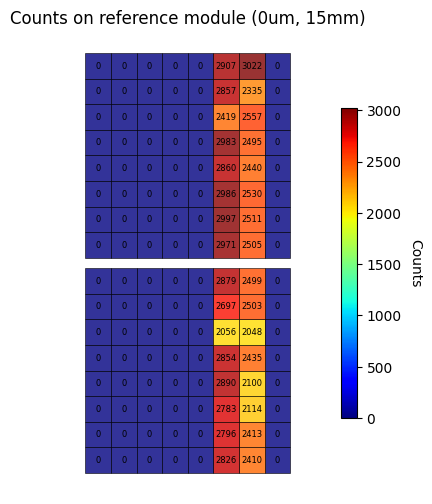

In [73]:
# Counts on reference module heatmap
data = doi_data[0][3]
print(pathslist[2][0])

eventcounts = np.zeros((128), dtype=np.int32)
ids = np.asarray(data[:, 3] % 128, dtype=np.int32)
np.add.at(eventcounts, ids, 1)
max_val = np.max(eventcounts)

def get_color(val):
    return plt.cm.jet(val / max_val)


fig, ax = plt.subplots(figsize=(4, 6))
for n in range(0, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        color_val = plt.cm.jet(eventcounts[n] / max_val)
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=color_val, alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, eventcounts[n], fontsize=6, ha='center', va='center')
    else:
        continue

plt.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0, 16)
plt.xlim(0, 8)
plt.axis('equal')

# Add colorbar
#vmax = 10322
#vmax = 8660
#vmax = 3490
vmax = 3022
sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax = max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label('Counts', rotation=270, labelpad=15)

plt.title(f'Counts on reference module (0um, 15mm)')
plt.show()

/tmp/ipykernel_767049/416170800.py:160: OptimizeWarning: Covariance of the parameters could not be estimated
  fit_p, _ = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])


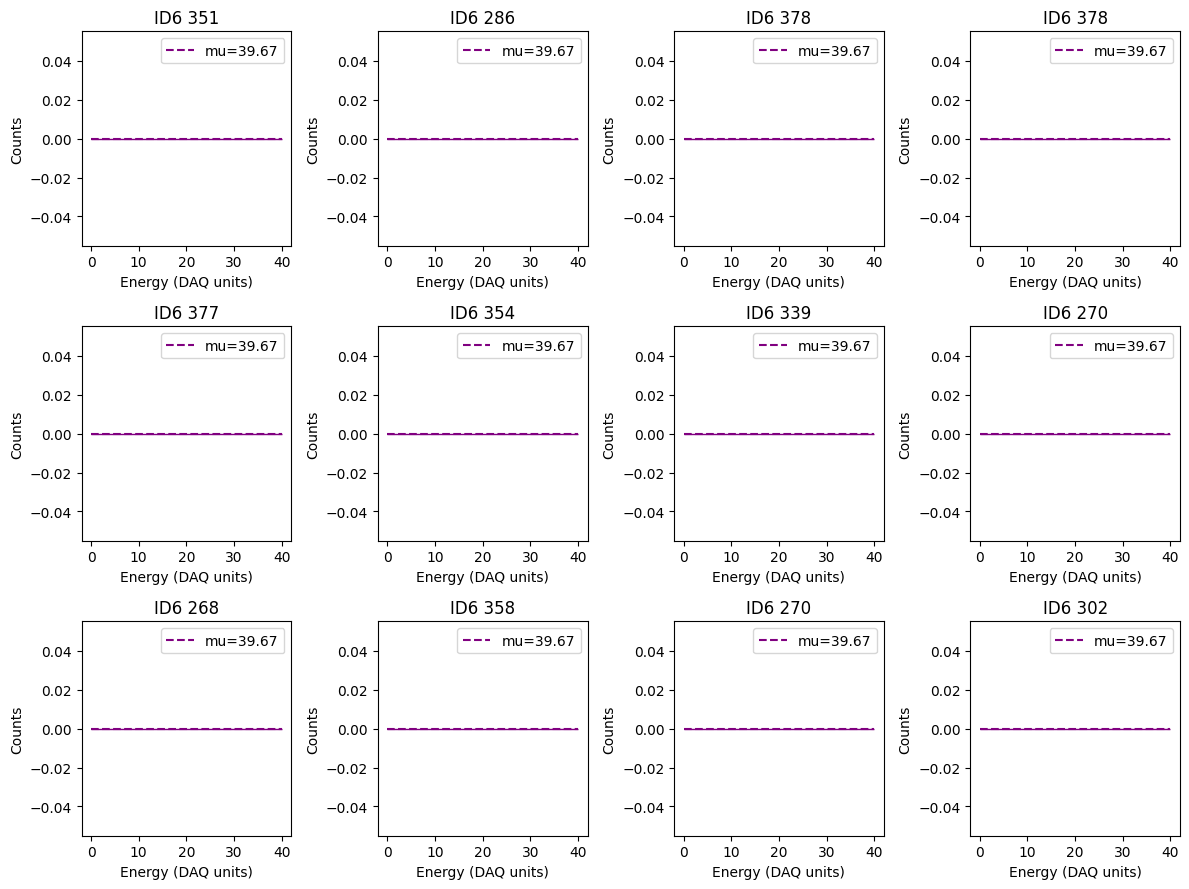

In [75]:
# Photopeak checks on reference module
data = doi_data[0][3]
fig, subplots = plt.subplots(3, 4, figsize=(12, 9))
subplots = subplots.flatten()
for i in range(12):
    randomid6 = random.randint(128*2, 128*2+128-1) 
    energies6 = data[:, 2][data[:, 3] == randomid6]
    hist, bins = subplots[i].hist(energies6, bins=60, range=(0, 40), color='purple', histtype='step')[0:2]
    bincenters = (bins[:-1] + bins[1:]) / 2
    fit_p = findPhotopeak(hist, bincenters)
    subplots[i].plot(np.linspace(0, 40, 100), gaussian(np.linspace(0, 40, 100), *fit_p), color='purple', linestyle='--', label=f'mu={fit_p[1]:.2f}')
    subplots[i].set_title(f'ID6 {randomid6}')
    subplots[i].set_xlabel('Energy (DAQ units)')
    subplots[i].set_ylabel('Counts')
    subplots[i].legend()
plt.tight_layout()
plt.show()

In [76]:
# Photopeak cuts on reference module
cut_sigma = 2.5
for i in range(len(doi_data)):
    for j in range(len(doi_data[i])):
        mask = np.zeros(len(doi_data[i][j]), dtype=bool)
        for k in range(128*2, 128*2+128):
            #print(len(doi_data[i][j][:, 2][doi_data[i][j][:, 3] == k]))
            if len(doi_data[i][j][:, 2][doi_data[i][j][:, 3] == k]) == 0:
                continue
            energies = doi_data[i][j][:, 2][doi_data[i][j][:, 3] == k]
            hist, bins = np.histogram(energies, bins=60, range=(0, 40))
            bincenters = (bins[:-1] + bins[1:]) / 2
            fit_p = findPhotopeak(hist, bincenters)
            bounds = [fit_p[1] - cut_sigma * fit_p[2], fit_p[1] + cut_sigma * fit_p[2]]
            thismask = (doi_data[i][j][:, 2] > bounds[0]) & (doi_data[i][j][:, 2] < bounds[1]) & (doi_data[i][j][:, 3] == k)
            mask = mask | thismask  
        doi_data[i][j] = doi_data[i][j][mask]
    

In [1]:
# Photopeak cuts, normalization and NCD
cut_sigma = 1.0

ncd_data = [] # same format as doi_data

# Compute and store photopeak fits for center data by crystal
photopeaks_dicts = []

# For all doi_data, apply cuts and normalization using the fits from data
for roughness in doi_data:
    currphotopeaks = {}
    curr_ncd_data = []
    for i in tqdm([3, 0, 1, 2, 4, 5, 6]):
        data = roughness[i]
        curr_curr_ncd_data = []
        for j in indicesL:
            channel = data[data[:, 5] % 128 == j]
            channel = channel[channel[:, 1] % 128 == get_compliment(j)]
            histL, binsL = np.histogram(channel[:, 0], bins=60, range=(0, 40))
            histR, binsR = np.histogram(channel[:, 4], bins=60, range=(0, 40))
            fit_pL = findPhotopeak(histL, binsL)
            fit_pR = findPhotopeak(histR, binsR)
            boundsL = [fit_pL[1] - cut_sigma * fit_pL[2], fit_pL[1] + cut_sigma * fit_pL[2]]
            boundsR = [fit_pR[1] - cut_sigma * fit_pR[2], fit_pR[1] + cut_sigma * fit_pR[2]]
            mask = (channel[:, 0] > boundsL[0]) & (channel[:, 0] < boundsL[1]) & (channel[:, 4] > boundsR[0]) & (channel[:, 4] < boundsR[1])
            channel = channel[mask]
            if j not in currphotopeaks:
                currphotopeaks[j] = (fit_pL, fit_pR)

            # Normalization
            fit_pL, fit_pR = currphotopeaks[j]
            channel[:, 0] = channel[:, 0] / fit_pL[1]
            channel[:, 4] = channel[:, 4] / fit_pR[1]
            
            # NCD
            ncd = (channel[:, 0] - channel[:, 4]) / (channel[:, 0] + channel[:, 4])
            curr_curr_ncd_data.append(ncd)
        curr_ncd_data.append(curr_curr_ncd_data)
    photopeaks_dicts.append(currphotopeaks)
    ncd_data.append(curr_ncd_data)
            

NameError: name 'doi_data' is not defined

100%|██████████| 4/4 [00:04<00:00,  1.02s/it]


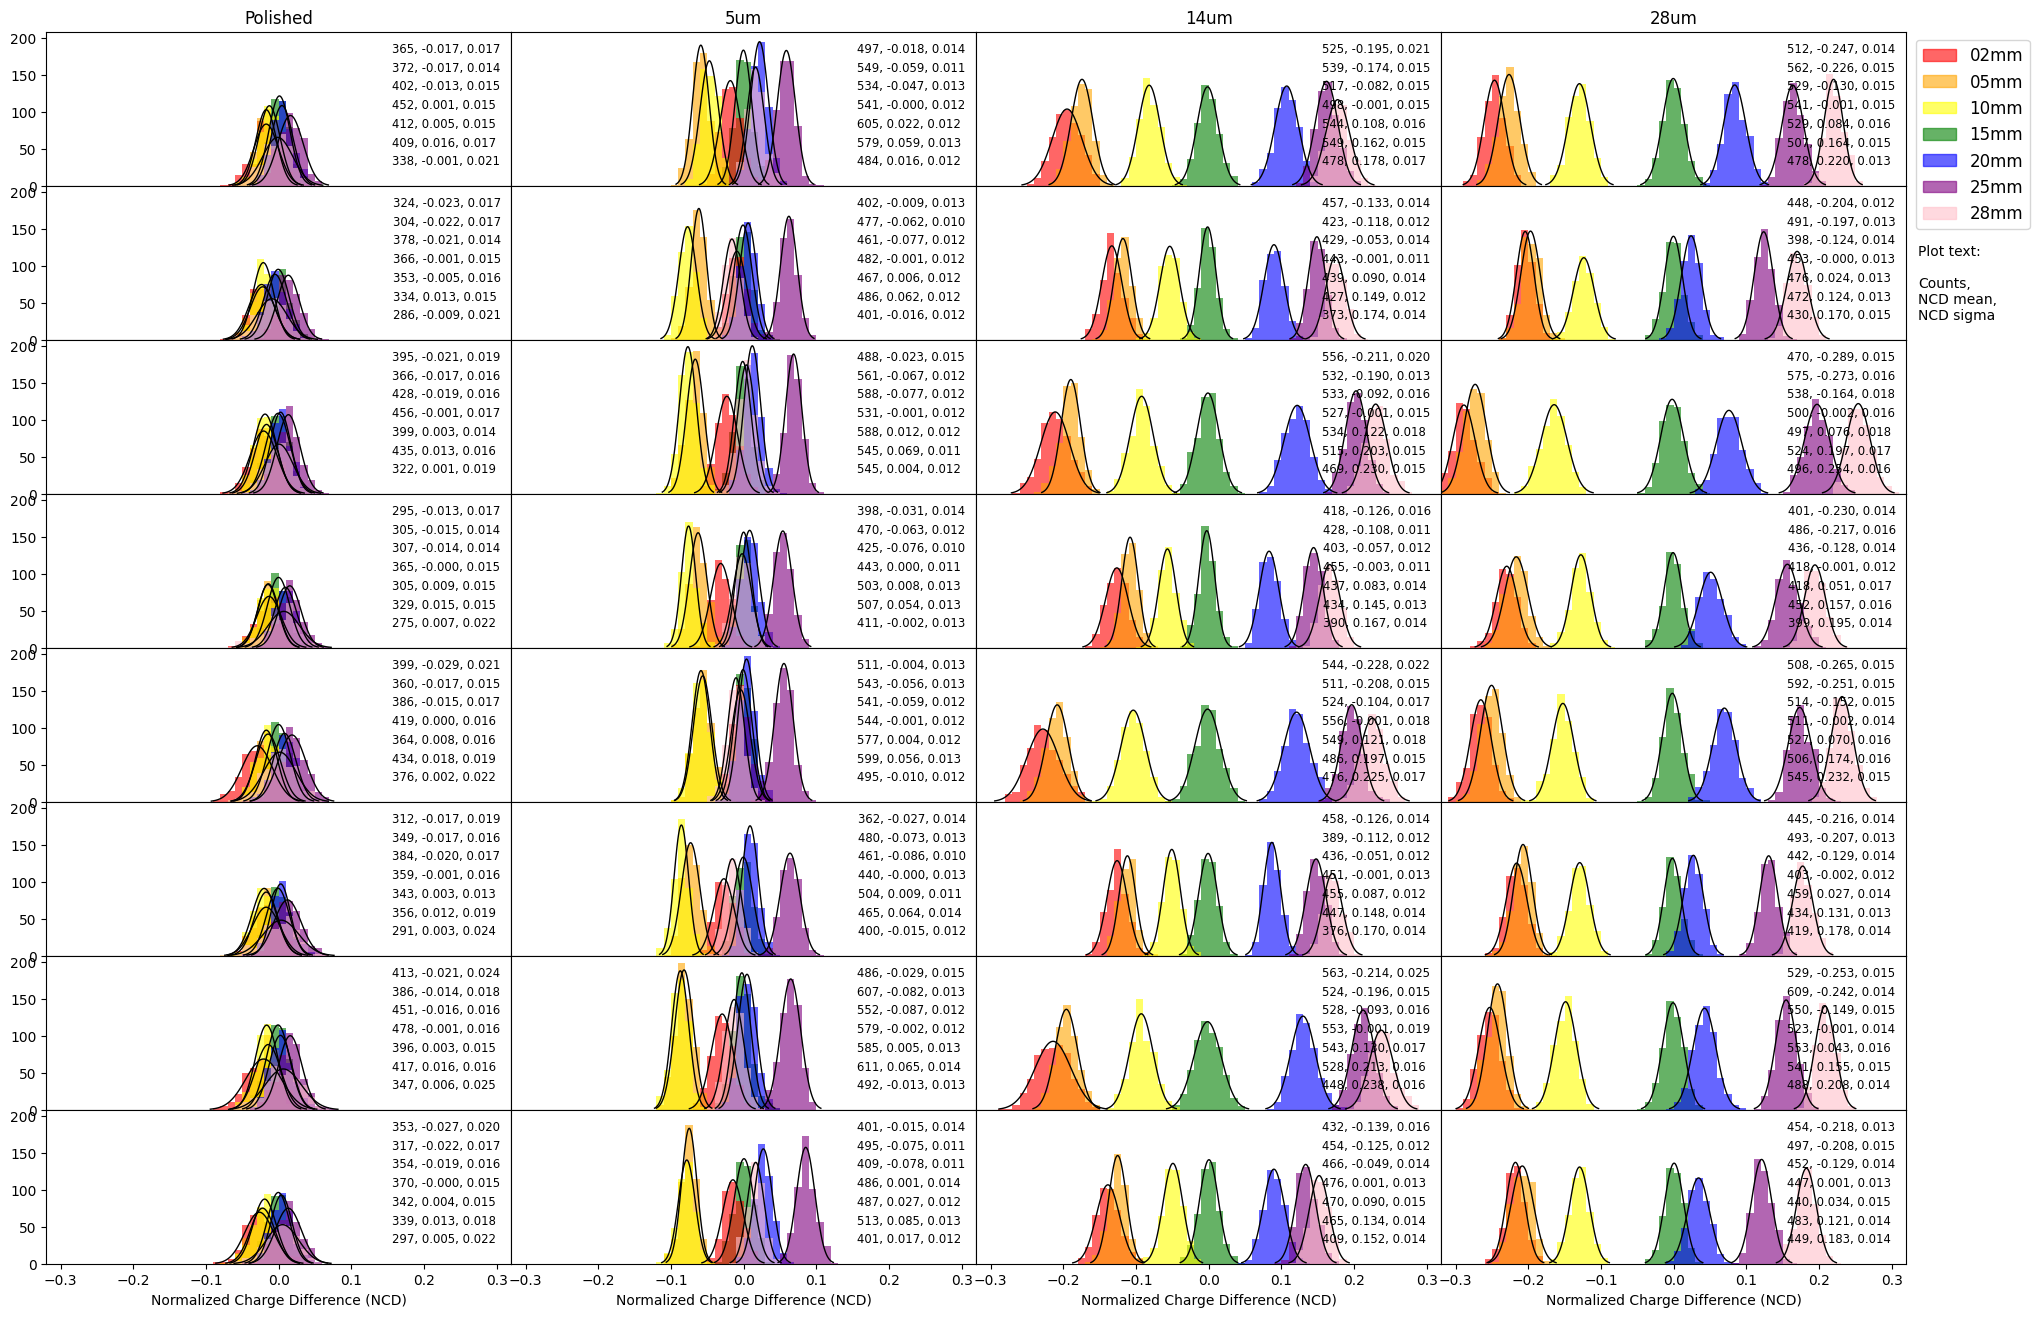

In [80]:
# Per crystal NCD, histogram form
fig, subplots = plt.subplots(8, 4, figsize=(24, 16))
subplots = subplots.flatten()

plot_range = (-0.32, 0.32)
colors = ['green', 'red', 'orange', 'yellow', 'blue', 'purple', 'pink']
popts = [[] for _ in range(32)]
plot_labels = [[] for _ in range(32)]

ymax = 0

for i in tqdm(range(4)): # loop over 4 roughnesses
    for j in range(7): # loop over 7 positions
        for k in range(8): # loop over 8 crystals
            ncds = ncd_data[i][j][k]
            hist, bins = subplots[k*4+i].hist(ncds, bins=64, range=plot_range, color=colors[j], alpha=0.6)[0:2]
            ymax = max(ymax, np.max(hist))
            bincenters = (bins[:-1] + bins[1:]) / 2
            popt, pcov = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 0.02])
            plotting_bounds = np.linspace(popt[1] - 3*popt[2], popt[1] + 3*popt[2], 100)
            subplots[k*4+i].plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='black', linewidth = 1, label=f'mu={popt[1]:.2f}')
            plot_labels[k*4+i].append(f'{len(ncds)}, {popt[1]:.3f}, {np.abs(popt[2]):.3f}')
            popts[k*4+i].append(popt)

for i in range(len(plot_labels)):
    legend_handles = []
    for j in range(len(plot_labels[i])):
        legend_handles.append(Patch(color=colors[j], alpha=0, label=plot_labels[i][j]))
    legend_handles.insert(3, legend_handles.pop(0))
    #legend_handles.append(Patch(color='black', alpha=0, label = f'{np.mean(np.array(popts[i])[:, 2]):.3f}'))
    subplots[i].legend(handles=legend_handles, loc='upper right', fontsize='small', frameon = False)

for ax in subplots:
    #ax.grid()
    ax.set_xlim(plot_range)
    ax.set_ylim(0, ymax + 10)
for ax in subplots[0:28]:
    ax.set_xticklabels([])
for i in range(0, 32):
    subplots[i].set_yticks([]) if i % 4 != 0 else None
plt.subplots_adjust(hspace=0, wspace=0) # Spacing
subplots[-4].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-3].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-2].set_xlabel('Normalized Charge Difference (NCD)')
subplots[-1].set_xlabel('Normalized Charge Difference (NCD)')
subplots[0].set_title('Polished')
subplots[1].set_title('5um')
subplots[2].set_title('14um')
subplots[3].set_title('28um')

names = ['15mm', '02mm', '05mm', '10mm', '20mm', '25mm', '28mm']
labels = [Patch(color=colors[j], label=names[j], alpha=0.6) for j in range(len(names))]
labels.insert(3, labels.pop(0))
fig.legend(handles=labels, bbox_to_anchor=(0.955, 0.88), fontsize='large')
fig.text(0.905, 0.70, 'Plot text:\n\nCounts,\nNCD mean,\nNCD sigma')
plt.show()


100%|██████████| 4/4 [00:00<00:00, 19.19it/s]


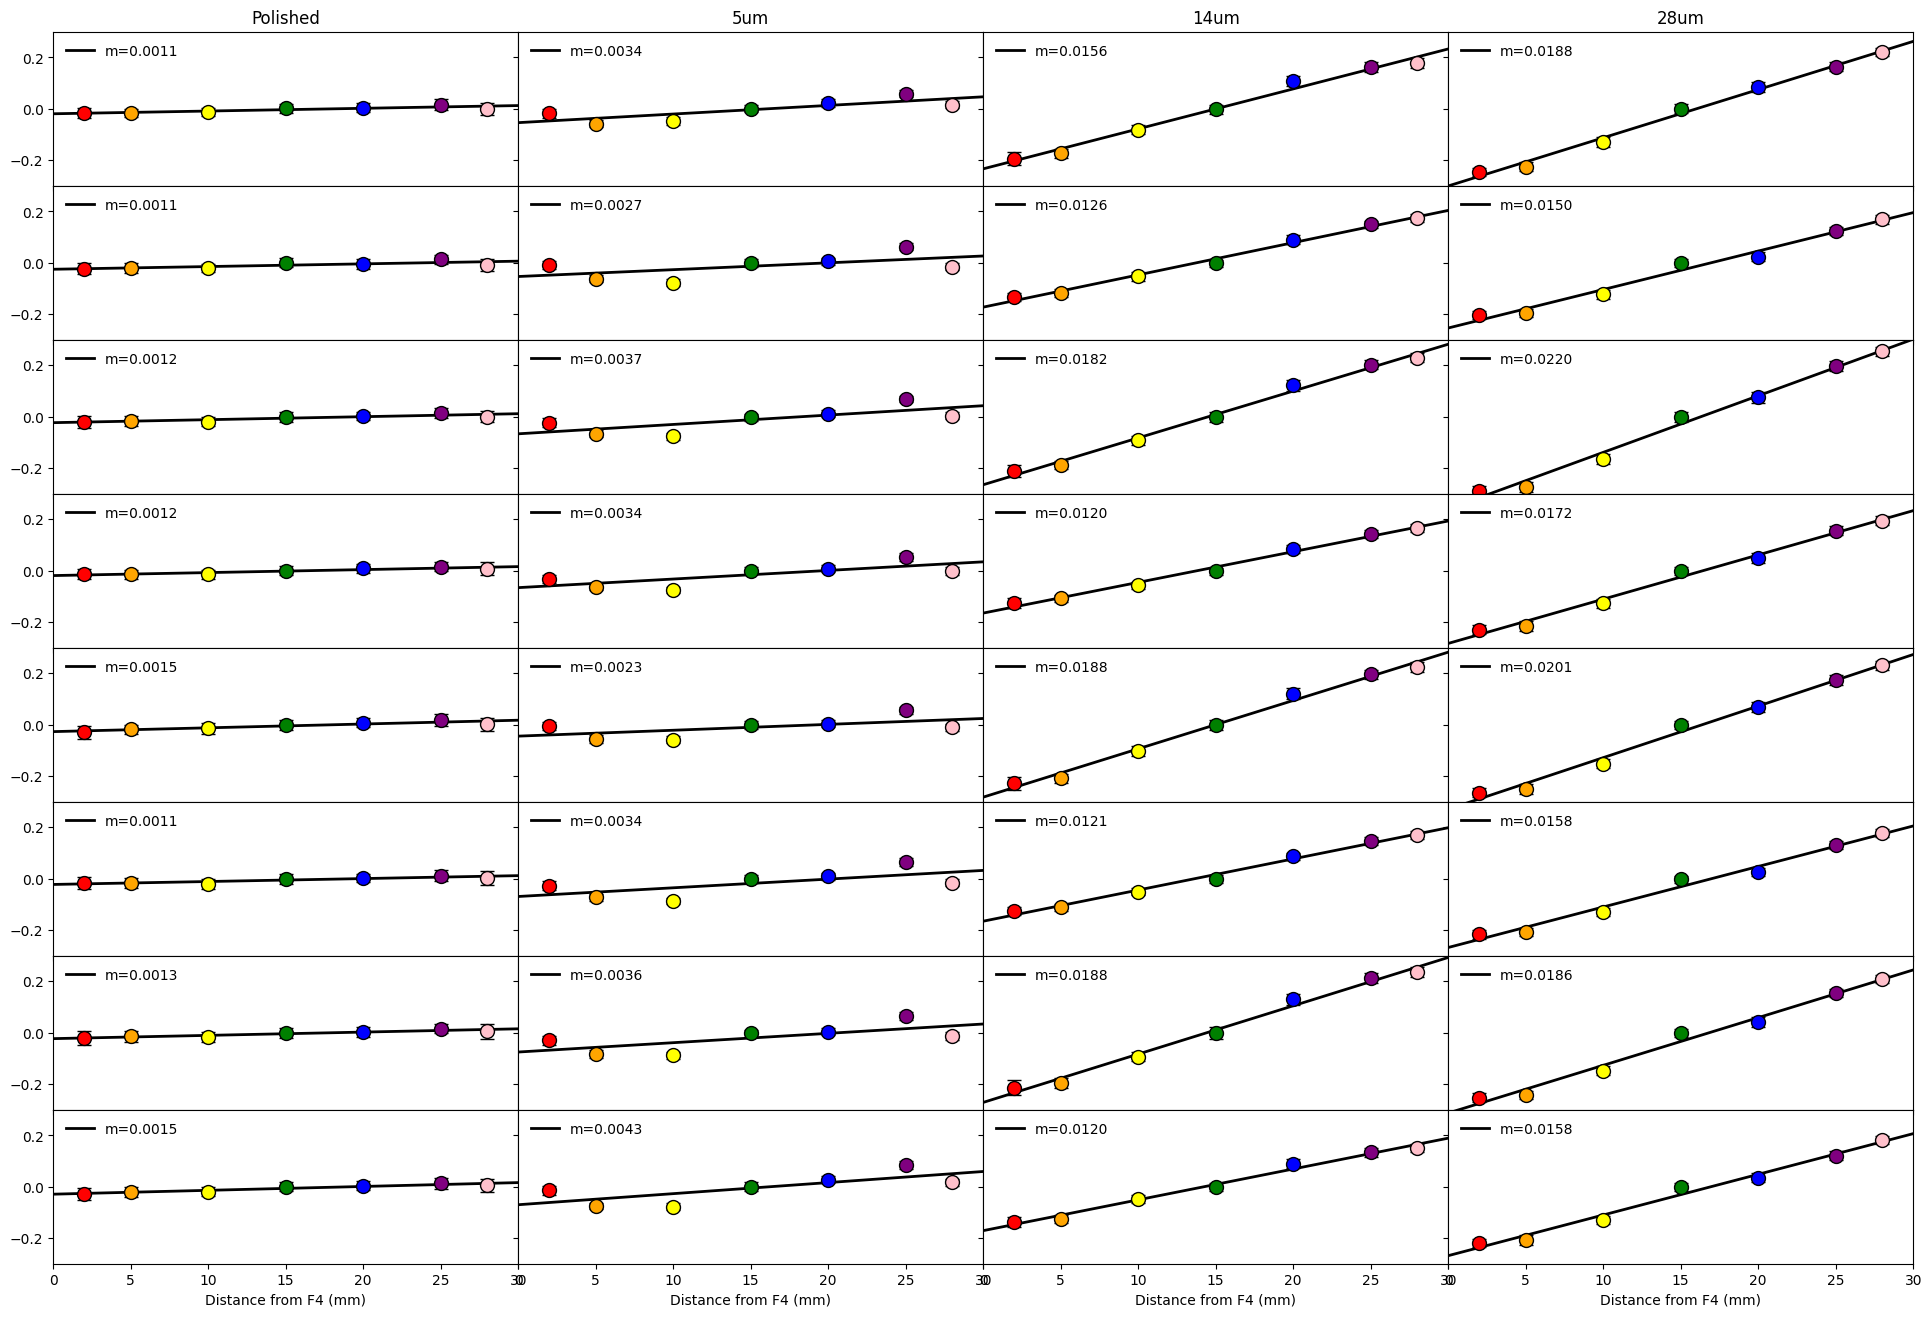

In [81]:
# Per crystal NCD, line plots

def linear(x, m, b):
    return m*x + b

fig, subplots = plt.subplots(8, 4, figsize=(24, 16))
subplots = subplots.flatten()
subplot_data = [[] for _ in range(32)]
distances = [15, 2, 5, 10, 20, 25, 28]

for i in tqdm(range(4)): # loop over 4 roughnesses
    for k in range(8): # loop over 8 crystals
        curr_popts = popts[k*4+i]
        means = [popt[1] for popt in curr_popts]
        for m in range(len(means)):
            subplots[k*4+i].errorbar(distances[m], curr_popts[m][1], 2.355/2*np.abs(curr_popts[m][2]), 
                            markerfacecolor = colors[m], markeredgecolor = 'black', fmt = 'o', 
                            markersize = 10, elinewidth = 2, capsize = 5, ecolor = 'black')
        popt, pcov = curve_fit(linear, distances, means)
        plotting_bounds = np.linspace(0, 30, 2)
        subplots[k*4+i].plot(plotting_bounds, linear(plotting_bounds, *popt), color = 'black', linewidth = 2, label = f'm={popt[0]:.4f}')
        subplots[k*4+i].legend(loc = 'upper left', frameon = False)

# Ensure all subplots share the x-axis and the same xticks, and remove space between plots
for ax in subplots:
    #ax.grid()
    ax.set_xlim(0, 30)
    ax.set_ylim(-0.30, 0.30)
for ax in subplots[0:28]:
    ax.set_xticklabels([])
for ax in [a for i, a in enumerate(subplots) if i % 4 != 0]:
    ax.set_yticklabels([])
plt.subplots_adjust(hspace=0, wspace=0) # Spacing

subplots[-4].set_xlabel('Distance from F4 (mm)')
subplots[-3].set_xlabel('Distance from F4 (mm)')
subplots[-2].set_xlabel('Distance from F4 (mm)')
subplots[-1].set_xlabel('Distance from F4 (mm)')
subplots[0].set_title('Polished')
subplots[1].set_title('5um')
subplots[2].set_title('14um')
subplots[3].set_title('28um')


plt.show()


In [28]:
# Photopeaks all channels, to be used in conjunction with the cell below
n = 3
data1 = doi_data[n][3]
data2 = doi_data[n][0]
print(pathslist[n][3])

/home/kale-chen/Documents/PET/DOI/Old Data/28um/28um_DOI_15mm_coinc.txt


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


5.494905299118706


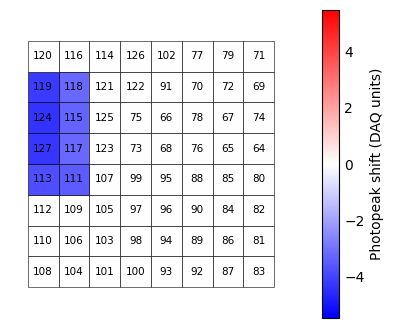

In [30]:
# To use in conjunction with the above cell
data1mus = np.zeros((8, 8))
data2mus = np.zeros((8, 8))

bins = np.linspace(0, 40, 60)
bincenters = (bins[:-1] + bins[1:]) / 2
for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    for i in range(len(list_indices)):
        energies1 = data1[:, 4][data1[:, 5] % 128 == list_indices[i]]
        energies2 = data2[:, 4][data2[:, 5] % 128 == list_indices[i]]
        hist1, _ = np.histogram(energies1, bins=60, range=(0, 40))
        hist2, _ = np.histogram(energies2, bins=60, range=(0, 40))
        fit_p1 = findPhotopeak(hist1, bincenters)
        fit_p2 = findPhotopeak(hist2, bincenters)
        data1mus[row-8, i] = fit_p1[1]
        data2mus[row-8, i] = fit_p2[1]

photopeak_shifts = data1mus - data2mus
max_shift = max(np.max(photopeak_shifts), np.abs(np.min(photopeak_shifts)))
print(max_shift)
def get_color(val):
    return plt.cm.bwr((val / max_shift) * 0.5 + 0.5)

fig, axes = plt.subplots(1, 2, figsize=(4.25, 4), gridspec_kw={'width_ratios': [4, 0.25]})

ax = axes[0]
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=get_color(photopeak_shifts[7-y, x]), alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(n), fontsize=7.5, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)

# Make the third subplot the colorbar:
cax = axes[1]
cb = plt.colorbar(
    ScalarMappable(cmap=plt.cm.bwr, norm=plt.Normalize(vmin=-max_shift, vmax=max_shift)),
    cax=cax,
    orientation='vertical'
)
cax.set_ylabel('Photopeak shift (DAQ units)')
# Remove ticks and labels on colorbar axes for aesthetics, optional:
cax.tick_params(axis='both', which='both', length=0)
plt.show()

In [92]:
print(doi_data[2][0])

[[ 17.194252 742.        22.45462  292.        26.104713 126.      ]
 [ 17.66193  722.        30.87326  326.        18.28912  112.      ]
 [  8.342911 720.        20.539703 326.         7.774876 113.      ]
 ...
 [ 14.690193 748.        27.182224 352.        16.073635  83.      ]
 [  9.932316 730.        19.67566  296.         9.631142 105.      ]
 [  3.987881 730.        26.80746  333.         3.950169 105.      ]]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[[ 9507.  6504.  5232.  4639.  3724.  3122.  3076.  2521.]
 [ 8928.  5505.  4359.  4031.  3372.  2708.  2480.  2159.]
 [ 8679.  5549.  4364.  3334.  2628.  2313.  1908.  2022.]
 [ 8464.  5421.  4141.  3457.  2797.  2234.  2314.  2209.]
 [ 8461.  5223.  4268.  3263.  2693.  2283.  2330.  2198.]
 [ 8839.  5307.  4010.  3306.  2809.  2461.  2419.  2345.]
 [ 8902.  6420.  5308.  4400.  3683.  2634.  2696.  2607.]
 [10643.  8197.  6607.  5685.  4990.  4155.  3778.  3628.]]
[[10918.  7315.  6403.  5373.  4519.  3898.  3456.  3101.]
 [10905.  7806.  5132.  4539.  3753.  3152.  2747.  2503.]
 [10509.  7402.  5171.  4469.  3474.  3115.  2509.  2398.]
 [10241.  7577.  4959.  4489.  3661.  2995.  2894.  2730.]
 [10532.  7482.  5201.  4294.  3690.  3074.  2953.  2683.]
 [10954.  6857.  5670.  4569.  3957.  3196.  2869.  2669.]
 [11497.  6951.  5803.  4874.  4083.  3473.  3442.  3211.]
 [13030.  8901.  7596.  6709.  5647.  4957.  4449.  4009.]]


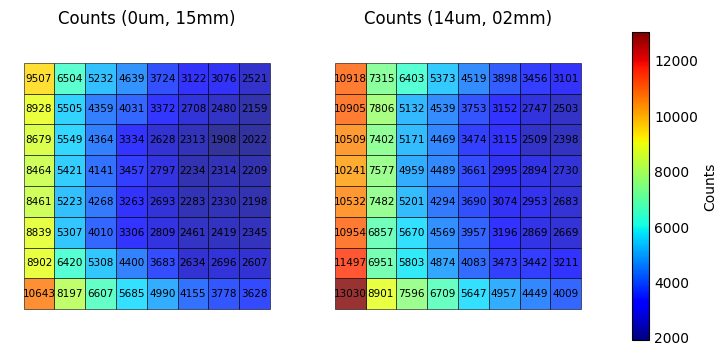

In [229]:
# Population heatmaps
center_counts = np.zeros((8, 8))
doi5mm_counts = np.zeros((8, 8))
data = doi_data[0][3]
data2 = doi_data[2][1]
for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    for i in range(len(list_indices)):
        mask = (data[:, 5] % 128 == list_indices[i]) & (data[:, 1] % 128 == get_compliment(list_indices[i]) % 128)
        center_counts[row-8, i] = len(data[mask])
        mask = (data2[:, 5] % 128 == list_indices[i]) & (data2[:, 1] % 128 == get_compliment(list_indices[i]) % 128)
        doi5mm_counts[row-8, i] = len(data2[mask])

print(center_counts)
print(doi5mm_counts)
max_counts = max(np.max(center_counts), np.max(doi5mm_counts))
min_counts = min(np.min(center_counts), np.min(doi5mm_counts))

def get_color(val):
    return plt.cm.jet((val - min_counts) / (max_counts - min_counts))

fig, axes = plt.subplots(1, 3, figsize=(8.25, 4), gridspec_kw={'width_ratios': [4, 4, 0.25]})

ax = axes[0]
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=get_color(center_counts[7-y, x]), alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(int(center_counts[7-y, x])), fontsize=7.5, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)
ax.set_title('Counts (0um, 15mm)')

ax = axes[1]
for n in range(64, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=get_color(doi5mm_counts[7-y, x]), alpha=0.8)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(int(doi5mm_counts[7-y, x])), fontsize=7.5, ha='center', va='center')
    else:
        continue

ax.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.axis('equal')
ax.set_ylim(-1, 9)
ax.set_xlim(-1, 9)
ax.set_title('Counts (14um, 02mm)')

# Make the third subplot the colorbar:
cax = axes[2]
cb = plt.colorbar(
    ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=min_counts, vmax=max_counts)),
    cax=cax,
    orientation='vertical'
)
cax.set_ylabel('Counts')
# Remove ticks and labels on colorbar axes for aesthetics, optional:
cax.tick_params(axis='both', which='both', length=0)
plt.show()

In [255]:
# Trying to reproduce these normalization values they have
import pandas as pd

csv0 = glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/0um', '*.csv'))[0]
csv5 = glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/4um', '*.csv'))[0]
csv14 = glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/14um', '*.csv'))[0]
csv28 = glob.glob(os.path.join(r'/home/kale-chen/Documents/PET/DOI/Old Data/28um', '*.csv'))[0]

n0 = np.asarray(pd.read_csv(csv0, header=None).iloc[:, 3][1:], dtype=np.float32)
n0n = n0 / np.max(n0)
n5 = np.asarray(pd.read_csv(csv5, header=None).iloc[:, 3][1:], dtype=np.float32)
n5n = n5 / np.max(n5)
n14 = np.asarray(pd.read_csv(csv14, header=None).iloc[:, 3][1:], dtype=np.float32)
n14n = n14 / np.max(n14)
n28 = np.asarray(pd.read_csv(csv28, header=None).iloc[:, 3][1:], dtype=np.float32)
n28n = n28 / np.max(n28)


In [ ]:
data = doi_data[0][3]
eventcounts = np.zeros(128, dtype=np.int32)
ids = np.asarray(data[:, 5] % 128, dtype=np.int32)
np.add.at(eventcounts, ids, 1)
eventcounts = np.sort(eventcounts)[::-1][:8]
eventcounts = 

[9075 8745 8638 8507 5680 5516 5459 5304]


In [ ]:
data = doi_data[0][3]
